In [0]:
customer_col=["customer_id","customer_name","city","state","customer_type"]
customer=spark.read.csv("/Volumes/assessment/retail/filestorage/customers1.csv").toDF(*customer_col)
customer.show()

+-----------+-------------+---------+-----------+-------------+
|customer_id|customer_name|     city|      state|customer_type|
+-----------+-------------+---------+-----------+-------------+
|       C101| Rahul Sharma|Hyderabad|  Telangana|      Premium|
|       C102|  Priya Reddy|Bangalore|  Karnataka|      Regular|
|       C103|   Amit Kumar|   Mumbai|Maharashtra|      Regular|
|       C104|  Sneha Patel|    Delhi|      Delhi|      Premium|
|       C105|   Farhan Ali|  Chennai| Tamil Nadu|      Regular|
|       C106|   Neha Singh|     Pune|Maharashtra|      Premium|
|       C107|  Arjun Verma|Hyderabad|  Telangana|      Regular|
|       C108|   Meera Nair|    Kochi|     Kerala|      Premium|
+-----------+-------------+---------+-----------+-------------+



In [0]:
product_col=["product_id","product_name","category","unit_price"]
product=spark.read.csv("/Volumes/assessment/retail/filestorage/products1.csv").toDF(*product_col)
product.show()

+----------+------------+-----------+----------+
|product_id|product_name|   category|unit_price|
+----------+------------+-----------+----------+
|      P101|      Laptop|Electronics|     65000|
|      P102|      Mobile|Electronics|     25000|
|      P103|       Chair|  Furniture|      7000|
|      P104|       Table|  Furniture|     12000|
|      P105|       Shoes|    Fashion|      4500|
|      P106|       Watch|    Fashion|      8000|
|      P107|          TV|Electronics|     45000|
|      P108|         Bag|    Fashion|      3000|
+----------+------------+-----------+----------+



In [0]:
orders_col=["order_id","customer_id","product_id","order_date","quantity","status"]
orders=spark.read.csv("/Volumes/assessment/retail/filestorage/Orders1.csv").toDF(*orders_col)
orders.show()


+--------+-----------+----------+----------+--------+---------+
|order_id|customer_id|product_id|order_date|quantity|   status|
+--------+-----------+----------+----------+--------+---------+
|   O1001|       C101|      P101|2026-06-01|       1|Completed|
|   O1002|       C102|      P102|2026-06-01|       2|Completed|
|   O1003|       C103|      P103|2026-06-02|       3|  Pending|
|   O1004|       C104|      P104|2026-06-02|       2|Completed|
|   O1005|       C105|      P105|2026-06-03|       4|Cancelled|
|   O1006|       C106|      P106|2026-06-03|       1|Completed|
|   O1007|       C107|      P107|2026-06-04|       1|Completed|
|   O1008|       C108|      P108|2026-06-04|       5|Completed|
|   O1009|       C101|      P102|2026-06-05|       1|Completed|
|   O1010|       C104|      P101|2026-06-05|       1|Completed|
+--------+-----------+----------+----------+--------+---------+



In [0]:
customer_preference2=spark.read.option("multiline", "true").json("/Volumes/assessment/retail/filestorage/customer_preferences.json")

In [0]:
customer.printSchema()
orders.printSchema()
product.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- quantity: string (nullable = true)
 |-- status: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: string (nullable = true)



In [0]:
spark.sql("CREATE SCHEMA IF NOT EXISTS assessment.bronze")
customer.write.format("delta").mode("overwrite").saveAsTable("assessment.bronze.customer")
orders.write.format("delta").mode("overwrite").saveAsTable("assessment.bronze.orders")
product.write.format("delta").mode("overwrite").saveAsTable("assessment.bronze.product")


In [0]:
customer_preference2.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("assessment.bronze.customer_preference2")

In [0]:
customer_preference2=customer_preference2.select("customer_id","preferred_channel","loyalty.points","loyalty.tier")


In [0]:
join_customer_prefer=customer.join(customer_preference2, customer.customer_id == customer_preference2.customer_id, "inner")
join_customer_prefer.show()


+-----------+-------------+---------+---------+-------------+-----------+-----------------+------+--------+
|customer_id|customer_name|     city|    state|customer_type|customer_id|preferred_channel|points|    tier|
+-----------+-------------+---------+---------+-------------+-----------+-----------------+------+--------+
|       C101| Rahul Sharma|Hyderabad|Telangana|      Premium|       C101|           Online|  1200|    Gold|
|       C102|  Priya Reddy|Bangalore|Karnataka|      Regular|       C102|            Store|   700|  Silver|
|       C104|  Sneha Patel|    Delhi|    Delhi|      Premium|       C104|           Online|  2200|Platinum|
|       C108|   Meera Nair|    Kochi|   Kerala|      Premium|       C108|       Mobile App|  1500|    Gold|
+-----------+-------------+---------+---------+-------------+-----------+-----------------+------+--------+



In [0]:
join_order_customer=orders.join(customer, on='customer_id', how='inner')
join_order_customer.show()

+-----------+--------+----------+----------+--------+---------+-------------+---------+-----------+-------------+
|customer_id|order_id|product_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|
+-----------+--------+----------+----------+--------+---------+-------------+---------+-----------+-------------+
|       C101|   O1001|      P101|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|
|       C102|   O1002|      P102|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|
|       C103|   O1003|      P103|2026-06-02|       3|  Pending|   Amit Kumar|   Mumbai|Maharashtra|      Regular|
|       C104|   O1004|      P104|2026-06-02|       2|Completed|  Sneha Patel|    Delhi|      Delhi|      Premium|
|       C105|   O1005|      P105|2026-06-03|       4|Cancelled|   Farhan Ali|  Chennai| Tamil Nadu|      Regular|
|       C106|   O1006|      P106|2026-06-03|       1|Completed|   Neha Singh|     Pune|M

In [0]:
# 1. Perform the join and handle the name collision immediately
join_order_product = orders.join(
    product, 
    orders.product_id == product.product_id, 
    "inner"
).select(
    orders.order_id,
    orders.customer_id,
    orders.product_id.alias("product_id_renamed"), # Renaming here
    orders.order_date,
    orders.quantity,
    orders.status,
    product.product_name,
    product.category,
    product.unit_price
)

# 2. Add the revenue column and select the final columns in one go
orders= join_order_product.withColumn(
    "revenue", 
    join_order_product["unit_price"].cast("float") * join_order_product["quantity"].cast("float")
).select(
    "order_id", 
    "customer_id", 
    "product_id_renamed", 
    "order_date", 
    "quantity", 
    "status", 
    "revenue"
)

final_df.show()

+--------+-----------+------------------+----------+--------+---------+-------+
|order_id|customer_id|product_id_renamed|order_date|quantity|   status|revenue|
+--------+-----------+------------------+----------+--------+---------+-------+
|   O1001|       C101|              P101|2026-06-01|       1|Completed|65000.0|
|   O1002|       C102|              P102|2026-06-01|       2|Completed|50000.0|
|   O1003|       C103|              P103|2026-06-02|       3|  Pending|21000.0|
|   O1004|       C104|              P104|2026-06-02|       2|Completed|24000.0|
|   O1005|       C105|              P105|2026-06-03|       4|Cancelled|18000.0|
|   O1006|       C106|              P106|2026-06-03|       1|Completed| 8000.0|
|   O1007|       C107|              P107|2026-06-04|       1|Completed|45000.0|
|   O1008|       C108|              P108|2026-06-04|       5|Completed|15000.0|
|   O1009|       C101|              P102|2026-06-05|       1|Completed|25000.0|
|   O1010|       C104|              P101

In [0]:
product.show()

+----------+------------+-----------+----------+
|product_id|product_name|   category|unit_price|
+----------+------------+-----------+----------+
|      P101|      Laptop|Electronics|     65000|
|      P102|      Mobile|Electronics|     25000|
|      P103|       Chair|  Furniture|      7000|
|      P104|       Table|  Furniture|     12000|
|      P105|       Shoes|    Fashion|      4500|
|      P106|       Watch|    Fashion|      8000|
|      P107|          TV|Electronics|     45000|
|      P108|         Bag|    Fashion|      3000|
+----------+------------+-----------+----------+



In [0]:
from pyspark.sql.functions import month
orders=orders.withColumn("month",month(col("order_date")))
orders.show()

+--------+-----------+------------------+----------+--------+---------+-------+-----+
|order_id|customer_id|product_id_renamed|order_date|quantity|   status|revenue|month|
+--------+-----------+------------------+----------+--------+---------+-------+-----+
|   O1001|       C101|              P101|2026-06-01|       1|Completed|65000.0|    6|
|   O1002|       C102|              P102|2026-06-01|       2|Completed|50000.0|    6|
|   O1003|       C103|              P103|2026-06-02|       3|  Pending|21000.0|    6|
|   O1004|       C104|              P104|2026-06-02|       2|Completed|24000.0|    6|
|   O1005|       C105|              P105|2026-06-03|       4|Cancelled|18000.0|    6|
|   O1006|       C106|              P106|2026-06-03|       1|Completed| 8000.0|    6|
|   O1007|       C107|              P107|2026-06-04|       1|Completed|45000.0|    6|
|   O1008|       C108|              P108|2026-06-04|       5|Completed|15000.0|    6|
|   O1009|       C101|              P102|2026-06-05|  

In [0]:
from pyspark.sql.functions import when
customer=customer.withColumn("customer_type",when(customer.customer_type=="Premium","High Value").otherwise("Standard Value"))
customer.show()

+-----------+-------------+---------+-----------+--------------+
|customer_id|customer_name|     city|      state| customer_type|
+-----------+-------------+---------+-----------+--------------+
|       C101| Rahul Sharma|Hyderabad|  Telangana|    High Value|
|       C102|  Priya Reddy|Bangalore|  Karnataka|Standard Value|
|       C103|   Amit Kumar|   Mumbai|Maharashtra|Standard Value|
|       C104|  Sneha Patel|    Delhi|      Delhi|    High Value|
|       C105|   Farhan Ali|  Chennai| Tamil Nadu|Standard Value|
|       C106|   Neha Singh|     Pune|Maharashtra|    High Value|
|       C107|  Arjun Verma|Hyderabad|  Telangana|Standard Value|
|       C108|   Meera Nair|    Kochi|     Kerala|    High Value|
+-----------+-------------+---------+-----------+--------------+



In [0]:
spark.sql("CREATE SCHEMA IF NOT EXISTS assessment.silver")
customer.write.format("delta").mode("overwrite").saveAsTable("assessment.silver.customer")
orders.write.format("delta").mode("overwrite").saveAsTable("assessment.silver.orders")
product.write.format("delta").mode("overwrite").saveAsTable("assessment.silver.product")
customer_preference2.write.format("delta").mode("overwrite").saveAsTable("assessment.silver.customer_preference2")


In [0]:
customer.createOrReplaceTempView("customer")
orders.createOrReplaceTempView("orders")
product.createOrReplaceTempView("product")
customer_preference2.createOrReplaceTempView("customer_preference2")



In [0]:
product.show()

+----------+------------+-----------+----------+
|product_id|product_name|   category|unit_price|
+----------+------------+-----------+----------+
|      P101|      Laptop|Electronics|     65000|
|      P102|      Mobile|Electronics|     25000|
|      P103|       Chair|  Furniture|      7000|
|      P104|       Table|  Furniture|     12000|
|      P105|       Shoes|    Fashion|      4500|
|      P106|       Watch|    Fashion|      8000|
|      P107|          TV|Electronics|     45000|
|      P108|         Bag|    Fashion|      3000|
+----------+------------+-----------+----------+



In [0]:
orders.show()

+--------+-----------+------------------+----------+--------+---------+-------+-----+
|order_id|customer_id|product_id_renamed|order_date|quantity|   status|revenue|month|
+--------+-----------+------------------+----------+--------+---------+-------+-----+
|   O1001|       C101|              P101|2026-06-01|       1|Completed|65000.0|    6|
|   O1002|       C102|              P102|2026-06-01|       2|Completed|50000.0|    6|
|   O1003|       C103|              P103|2026-06-02|       3|  Pending|21000.0|    6|
|   O1004|       C104|              P104|2026-06-02|       2|Completed|24000.0|    6|
|   O1005|       C105|              P105|2026-06-03|       4|Cancelled|18000.0|    6|
|   O1006|       C106|              P106|2026-06-03|       1|Completed| 8000.0|    6|
|   O1007|       C107|              P107|2026-06-04|       1|Completed|45000.0|    6|
|   O1008|       C108|              P108|2026-06-04|       5|Completed|15000.0|    6|
|   O1009|       C101|              P102|2026-06-05|  

In [0]:
result=spark.sql("select sum(revenue) from orders")
result.show()

+------------+
|sum(revenue)|
+------------+
|    336000.0|
+------------+



In [0]:
revenue_by_city=spark.sql("select c.city, sum(o.revenue) as total_revenue from customer c join orders o on c.customer_id=o.customer_id group by c.city")
revenue_by_city.show()

+---------+-------------+
|     city|total_revenue|
+---------+-------------+
|    Delhi|      89000.0|
|  Chennai|      18000.0|
|    Kochi|      15000.0|
|Hyderabad|     135000.0|
|Bangalore|      50000.0|
|     Pune|       8000.0|
|   Mumbai|      21000.0|
+---------+-------------+



In [0]:
revenue_by_category=spark.sql("select p.category, sum(o.revenue) as total_revenue from product p join orders o on p.product_id=o.product_id_renamed group by p.category")
revenue_by_category.show()

+-----------+-------------+
|   category|total_revenue|
+-----------+-------------+
|Electronics|     250000.0|
|  Furniture|      45000.0|
|    Fashion|      41000.0|
+-----------+-------------+



In [0]:
revenue_by_customer=spark.sql("select c.customer_id, sum(o.revenue) as total_revenue from customer c join orders o on c.customer_id=o.customer_id group by c.customer_id order by sum(o.revenue) desc limit 1")
revenue_by_customer.show()


+-----------+-------------+
|customer_id|total_revenue|
+-----------+-------------+
|       C101|      90000.0|
+-----------+-------------+



In [0]:
result=spark.sql("select sum(revenue) from orders where status='Completed'")
result.show()
revenue_by_city=spark.sql("select c.city, sum(o.revenue) as total_revenue from customer c join orders o on c.customer_id=o.customer_id where o.status='Completed' group by c.city")
revenue_by_city.show()
revenue_by_category=spark.sql("select p.category, sum(o.revenue) as total_revenue from product p join orders o on p.product_id=o.product_id_renamed where o.status='Completed' group by p.category")
revenue_by_category.show()
revenue_by_customer=spark.sql("select c.customer_id, sum(o.revenue) as total_revenue from customer c join orders o on c.customer_id=o.customer_id where o.status='Completed' group by c.customer_id order by sum(o.revenue) desc limit 1")
revenue_by_customer.show()

+------------+
|sum(revenue)|
+------------+
|    297000.0|
+------------+

+---------+-------------+
|     city|total_revenue|
+---------+-------------+
|    Delhi|      89000.0|
|    Kochi|      15000.0|
|Hyderabad|     135000.0|
|Bangalore|      50000.0|
|     Pune|       8000.0|
+---------+-------------+

+-----------+-------------+
|   category|total_revenue|
+-----------+-------------+
|Electronics|     250000.0|
|  Furniture|      24000.0|
|    Fashion|      23000.0|
+-----------+-------------+

+-----------+-------------+
|customer_id|total_revenue|
+-----------+-------------+
|       C101|      90000.0|
+-----------+-------------+



In [0]:
from pyspark.sql.functions import rank,col
from pyspark.sql.window import Window
window_spec=Window.orderBy(desc("revenue"))
join_order_product=join_order_product.withColumn("revenue", col("unit_price").cast("double")*col("quantity").cast("double"))
join_order_product=join_order_product.groupBy("product_id_renamed").agg(sum("revenue").alias("revenue"))
order_product=join_order_product.withColumn("rank",rank().over(window_spec))
display(order_product)


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


product_id_renamed,revenue,rank
P101,130000.0,1
P102,75000.0,2
P107,45000.0,3
P104,24000.0,4
P103,21000.0,5
P105,18000.0,6
P108,15000.0,7
P106,8000.0,8


In [0]:
join_order_customer = orders.join(
    customer, 
    orders.customer_id == customer.customer_id, 
    "inner"
).select(
    orders.order_id,
    orders.customer_id,
    orders.product_id_renamed, # Renaming here
    orders.order_date,
    orders.quantity,
    orders.revenue,
    orders.status,
    customer.customer_name,
    customer.city,
    customer.state,
    customer.customer_type,

)



In [0]:

join_order_customer=join_order_customer.groupBy("customer_id").agg(sum("revenue").alias("revenue"))
order_customer=join_order_customer.withColumn("rank",rank().over(window_spec)).toDF("customer_id","revenue","rank")
order_customer.show()
order_customer.show(3)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------+----+
|customer_id|revenue|rank|
+-----------+-------+----+
|       C101|90000.0|   1|
|       C104|89000.0|   2|
|       C102|50000.0|   3|
|       C107|45000.0|   4|
|       C103|21000.0|   5|
|       C105|18000.0|   6|
|       C108|15000.0|   7|
|       C106| 8000.0|   8|
+-----------+-------+----+

+-----------+-------+----+
|customer_id|revenue|rank|
+-----------+-------+----+
|       C101|90000.0|   1|
|       C104|89000.0|   2|
|       C102|50000.0|   3|
+-----------+-------+----+
only showing top 3 rows


In [0]:
from pyspark.sql.functions import sum as sum, rank, col
from pyspark.sql.window import Window

join_order_product = orders.join(product, orders.product_id_renamed == product.product_id, "inner")
product_revenue = join_order_product.groupBy("category", "product_id_renamed", "product_name").agg(sum("revenue").alias("total_revenue"))
window_spec_category = Window.partitionBy("category").orderBy(col("total_revenue").desc())
top_product_per_category = product_revenue.withColumn("rank", rank().over(window_spec_category)).filter(col("rank") == 1)
display(top_product_per_category)

running_revenue_window = Window.orderBy("order_date").rowsBetween(Window.unboundedPreceding, Window.currentRow)
orders_running_revenue = orders.withColumn("running_revenue", sum("revenue").over(running_revenue_window))
display(orders_running_revenue.select("order_date", "revenue", "running_revenue"))

category,product_id_renamed,product_name,total_revenue,rank
Electronics,P101,Laptop,130000.0,1
Fashion,P105,Shoes,18000.0,1
Furniture,P104,Table,24000.0,1


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


order_date,revenue,running_revenue
2026-06-01,65000.0,65000.0
2026-06-01,50000.0,115000.0
2026-06-02,21000.0,136000.0
2026-06-02,24000.0,160000.0
2026-06-03,18000.0,178000.0
2026-06-03,8000.0,186000.0
2026-06-04,45000.0,231000.0
2026-06-04,15000.0,246000.0
2026-06-05,25000.0,271000.0
2026-06-05,65000.0,336000.0


In [0]:

customer.write.format("delta").mode("overwrite").save("/tmp/delta/customer")
product.write.format("delta").mode("overwrite").save("/tmp/delta/product")
customer_preference2.write.format("delta").mode("overwrite").save("/tmp/delta/customer_preference2")
orders.write.format("delta").mode("overwrite").save("/tmp/delta/orders")

customer.write.format("delta").mode("overwrite").saveAsTable("customer_delta")
product.write.format("delta").mode("overwrite").saveAsTable("product_delta")
customer_preference2.write.format("delta").mode("overwrite").saveAsTable("customer_preference2_delta")
orders.write.format("delta").mode("overwrite").saveAsTable("orders_delta")

# Create Delta table using SQL
spark.sql("""
CREATE TABLE customer_sql_delta1
USING DELTA
AS SELECT * FROM customer
""")
spark.sql("""
CREATE TABLE product_sql_delta1
USING DELTA
AS SELECT * FROM product
""")
spark.sql("""
CREATE TABLE customer_preference2_sql_delta1
USING DELTA
AS SELECT * FROM customer_preference2
""")
spark.sql("""
CREATE TABLE orders_sql_delta2
USING DELTA
AS SELECT * FROM orders
""")

DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
result1=spark.sql("DESCRIBE HISTORY customer_delta")
result1.show()

+-------+-------------------+---------------+--------------------+--------------------+--------------------+----+------------------+-----------------------+--------------------+-----------+-----------------+-------------+--------------------+------------+--------------------+
|version|          timestamp|         userId|            userName|           operation| operationParameters| job|          notebook|queryHistoryStatementId|           clusterId|readVersion|   isolationLevel|isBlindAppend|    operationMetrics|userMetadata|          engineInfo|
+-------+-------------------+---------------+--------------------+--------------------+--------------------+----+------------------+-----------------------+--------------------+-----------+-----------------+-------------+--------------------+------------+--------------------+
|      2|2026-06-22 06:41:07|143858548260578|azuser7214_mml.lo...|CREATE OR REPLACE...|{isV1SaveAsTableO...|NULL|{3363232700231932}|   a07f4190-80e7-44f...|0622-040546-2

In [0]:
previous_version_df = spark.read.format("delta").option("versionAsOf", 0).load("/tmp/delta/customer")
display(previous_version_df)

customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Hyderabad,Telangana,High Value
C102,Priya Reddy,Bangalore,Karnataka,Standard Value
C103,Amit Kumar,Mumbai,Maharashtra,Standard Value
C104,Sneha Patel,Delhi,Delhi,High Value
C105,Farhan Ali,Chennai,Tamil Nadu,Standard Value
C106,Neha Singh,Pune,Maharashtra,High Value
C107,Arjun Verma,Hyderabad,Telangana,Standard Value
C108,Meera Nair,Kochi,Kerala,High Value


In [0]:

from delta.tables import DeltaTable

delta_customer = DeltaTable.forPath(spark, "/tmp/delta/customer")
delta_customer.alias("target").merge(
    customer.alias("source"),
    "target.customer_id = source.customer_id"
).whenMatchedUpdateAll().whenNotMatchedInsertAll().execute()




DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:

history = spark.sql("DESCRIBE HISTORY customer_delta")
display(history)




version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
2,2026-06-22T06:41:07.000Z,143858548260578,azuser7214_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(3363232700231932),a07f4190-80e7-44f4-97da-b2ece36f0f6f,0622-040546-2m6hnsy1-v2n,1,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 1, numRemovedBytes -> 1945, numDeletionVectorsRemoved -> 0, numOutputRows -> 8, numOutputBytes -> 1945)",null,Databricks-Runtime/18.2.x-photon-scala2.13
1,2026-06-22T06:40:37.000Z,143858548260578,azuser7214_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(3363232700231932),15e96efc-38ad-49a4-8d6b-87b395e1dfc0,0622-040546-2m6hnsy1-v2n,0,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 1, numRemovedBytes -> 1945, numDeletionVectorsRemoved -> 0, numOutputRows -> 8, numOutputBytes -> 1945)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-22T06:40:09.000Z,143858548260578,azuser7214_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(3363232700231932),38f014f8-3512-4ca6-a56c-ee6a62469d83,0622-040546-2m6hnsy1-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 8, numOutputBytes -> 1945)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:

spark.sql("OPTIMIZE customer_delta")


DataFrame[path: string, metrics: struct<numFilesAdded:bigint,numFilesRemoved:bigint,filesAdded:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesRemoved:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,partitionsOptimized:bigint,zOrderStats:struct<strategyName:string,inputCubeFiles:struct<num:bigint,size:bigint>,inputOtherFiles:struct<num:bigint,size:bigint>,inputNumCubes:bigint,mergedFiles:struct<num:bigint,size:bigint>,numOutputCubes:bigint,mergedNumCubes:bigint>,clusteringStats:struct<inputZCubeFiles:struct<numFiles:bigint,size:bigint>,inputOtherFiles:struct<numFiles:bigint,size:bigint>,inputNumZCubes:bigint,mergedFiles:struct<numFiles:bigint,size:bigint>,numOutputZCubes:bigint>,numBins:bigint,numBatches:bigint,totalConsideredFiles:bigint,totalFilesSkipped:bigint,preserveInsertionOrder:boolean,numFilesSkippedToReduceWriteAmplification:bigint,numBytesSkippedToReduceWriteAmplification:bigint,startTimeMs:bigint,endTimeMs:bigint,

In [0]:

result=spark.sql("OPTIMIZE customer_delta ZORDER BY (city)")
result.show()


+--------------------+--------------------+
|                path|             metrics|
+--------------------+--------------------+
|abfss://unity-cat...|{0, 0, {NULL, NUL...|
+--------------------+--------------------+



In [0]:

spark.sql("VACUUM customer_delta RETAIN 168 HOURS")

DataFrame[path: string]

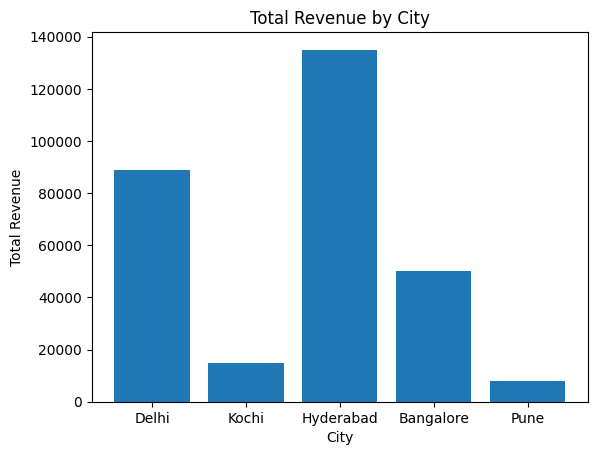

In [0]:
import matplotlib.pyplot as plt
plt.bar(revenue_by_city.toPandas()["city"],revenue_by_city.toPandas()["total_revenue"])
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by City")
plt.show()

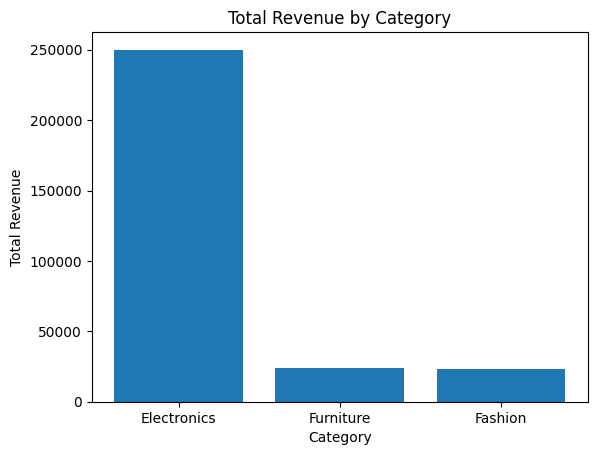

In [0]:
plt.bar(revenue_by_category.toPandas()["category"],revenue_by_category.toPandas()["total_revenue"])
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Category")
plt.show()


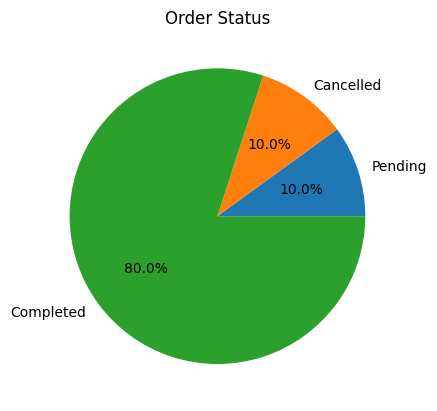

In [0]:
order_status=orders.groupBy("status").count()
plt.pie(order_status.toPandas()["count"],labels=order_status.toPandas()["status"],autopct='%1.1f%%')
plt.title("Order Status")
plt.show()

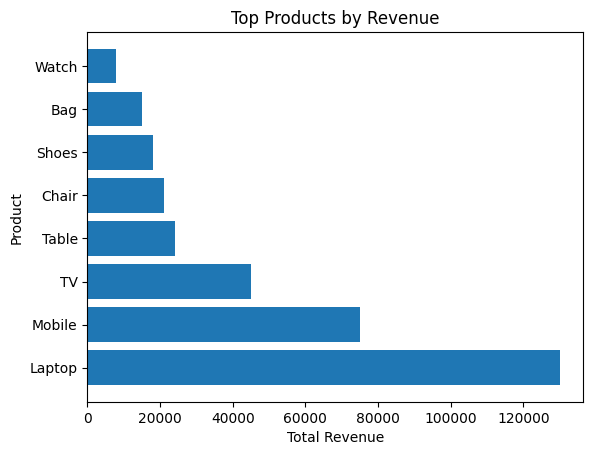

In [0]:
revenue_by_product = join_order_product.groupBy("product_name").sum("revenue")
top_products = revenue_by_product.orderBy(col("sum(revenue)").desc()).limit(10)
plt.barh(top_products.toPandas()["product_name"], top_products.toPandas()["sum(revenue)"])
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.title("Top Products by Revenue")
plt.show()

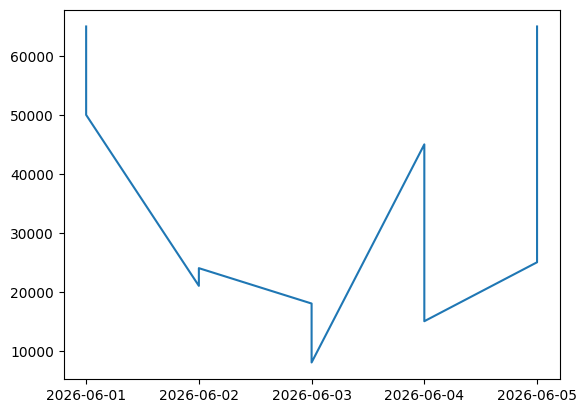

In [0]:
plt.plot(orders.select("order_date").toPandas()["order_date"], orders.select("revenue").toPandas()["revenue"])
plt.show()

In [0]:
spark.sql("""
CREATE TABLE managed_customer (
    customer_id STRING,
    customer_name STRING,
    city STRING,
    state STRING,
    customer_type STRING
)
USING DELTA
""")

DataFrame[]

In [0]:
%sql
-- Creates a managed Delta table in assessment.silver
-- (LOCATION removed: the original path overlapped with UC managed storage)
CREATE TABLE IF NOT EXISTS assessment.silver.product_external
(
  product_id STRING,
  product_name STRING,
  category STRING,
  unit_price DOUBLE
)
USING DELTA;

In [0]:
# Create a local temporary view
orders.createOrReplaceTempView("orders_temp")

